October 10 2025

**Data provenance**

The dataset includes microstructural images collected from (i) a Ti–6Al–4V (Ti64) alloy sample, and (ii) Nb alloy. The images were acquired using optical/Laser microscopy



**What you’ll find here**

Raw metallographic/SEM images of alloy microstructures.

Baseline segmentation examples (e.g., k-means, thresholding) to illustrate challenges such as streak artifacts or misclassification.

**What you will do**

**Apply segmentation methods**  and record your observations.

**Compare techniques** and comment on their strengths and limitations.

**Visualize results** by overlaying predicted features or segmentation masks onto the original images.

# Importing data

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans

In [ ]:
!gdown --fuzzy https://drive.google.com/file/d/1cS4aWLKAhwiXSHz23Yb8FEvyBFOO_U4C/view?usp=sharing
!gdown --fuzzy https://drive.google.com/file/d/1H4GwZYJyhDVoFPfA1_cT_8xQNvcAmuk1/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1cS4aWLKAhwiXSHz23Yb8FEvyBFOO_U4C
To: /content/Ti64.png
100% 997k/997k [00:00<00:00, 159MB/s]
Downloading...
From: https://drive.google.com/uc?id=1H4GwZYJyhDVoFPfA1_cT_8xQNvcAmuk1
To: /content/MultiPhase_w_Dislocations.tif
100% 1.88M/1.88M [00:00<00:00, 169MB/s]


## 1.Ti64

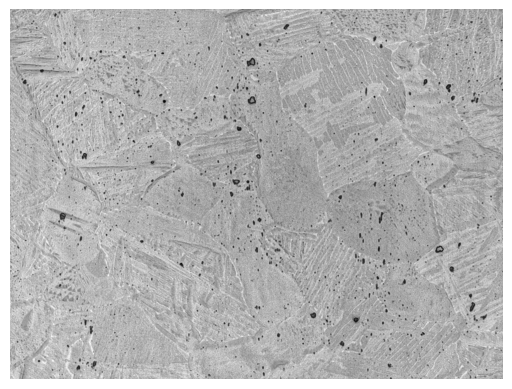

In [ ]:
img1 = mpimg.imread("Ti64.png")
plt.imshow(img1)
plt.axis("off")
plt.show()


**What you see in the image**

The grayscale image above is a microscopy snapshot of Ti–6Al–4V (Ti64), a widely used aerospace alloy. Its internal structure has two major building blocks:

1.   α phase (alpha, light regions): Appears as the lighter gray regions. The α phase is stable at room temperature and gives the alloy strength.
2.   β phase (beta, darker regions): Seen as the darker intergranular regions. The β phase provides ductility (ability to bend/stretch).
3.   The small black spots visible across the sample are not another phase but likely surface dirt or minor preparation artifacts, not intrinsic features of the material.

**Why this matters**


Being able to classify which pixel belongs to α or β is the first step that lays the foundation for all subsequent characterization.

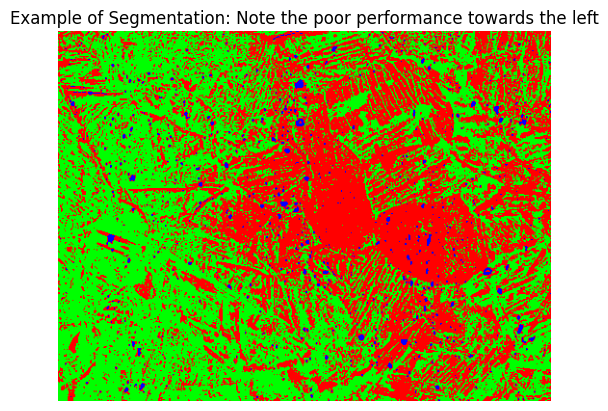

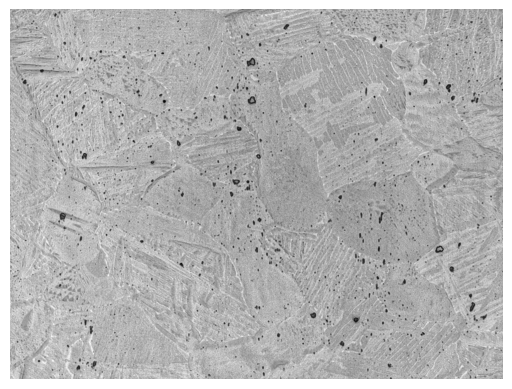

In [ ]:
# image saved as img1
plt.imshow(img1)
plt.axis("off")
plt.show()

## 2.Niobium alloy showing phases, dislocations, and cracks

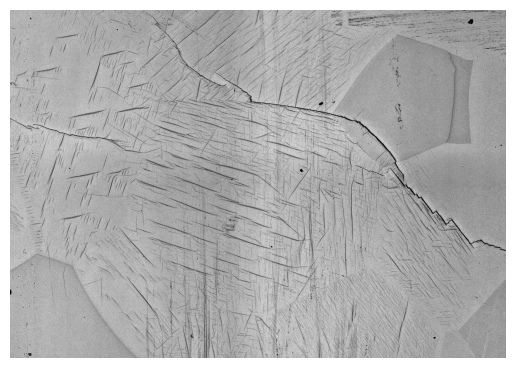

In [ ]:
img2 = mpimg.imread("MultiPhase_w_Dislocations.tif")
plt.imshow(img2)
plt.axis("off")
plt.show()

This image shows a niobium (Nb) based alloy containing multiple phases and visible defects/dislocations.

**Phases:**

Nb alloys typically contain distinct crystalline regions (phases). Each phase has different contrast in the image because they scatter or absorb light/electrons differently.



*   **Phase A**: Different Grains
*   **Phase B (darker)**: Secondary precipitates or solute-rich regions showing as small cracks








**Artifacts**

* **Black spots:** Defects
* **Polishing artifact**: Visible on the top right of the image


**Deformation Features**

* **Cracking:** Two distinct cracks propagating through the microstructure.


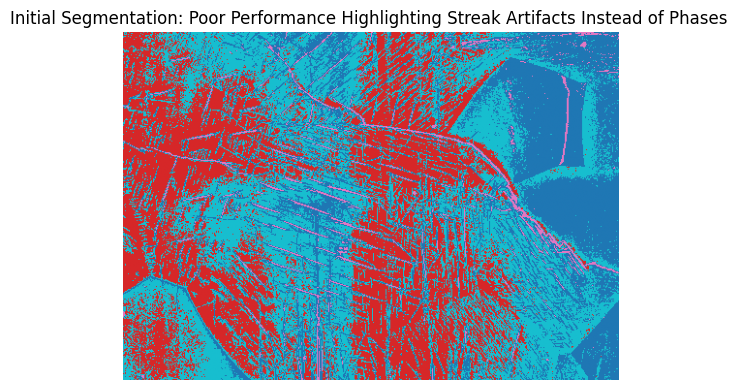

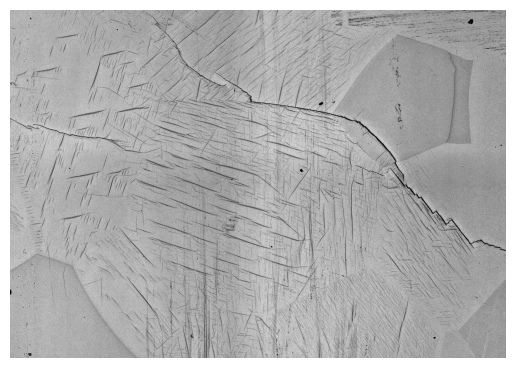

In [ ]:
# image saved as img2
plt.imshow(img2)
plt.axis("off")
plt.show()

# Hackathon Day 2!

October 10, 2025, Sergei V. Kalinin

My plan is to incorporate the simple sliding window transform combined with the Radon transform to find the orientation of the cracks.

# Sliding Radon transform

In [ ]:
img2.shape
img = img2.sum(axis = 2)
img.shape

(664, 946)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon, iradon
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [ ]:
def radon_gmm_segmentation(
    img,
    window_size=(32, 32),
    stride=(16, 16),
    thetas=np.linspace(0, 180, 61, endpoint=False),
    n_components=3,
    standardize=True,
    random_state=0,
):
    """
    Sliding-window Radon + GMM clustering on Radon features.

    Parameters
    ----------
    img : (H, W) ndarray
        Grayscale image.
    window_size : (int, int)
        (win_h, win_w) for the sliding window.
    stride : (int, int)
        (stride_h, stride_w) step between windows.
    thetas : 1D ndarray
        Projection angles for Radon transform in degrees.
    n_components : int
        Number of GMM clusters.
    standardize : bool
        Z-score features before GMM fit (recommended).
    random_state : int
        RNG seed for reproducibility.

    Returns
    -------
    results : dict
        {
            'label_grid': (n_rows, n_cols) int array of window labels,
            'labels_per_window': (N,) labels in raster scan order,
            'probs': (N, K) responsibilities,
            'weights': (K,) mixture weights,
            'endmember_sinograms': list of (R, T) arrays,
            'prototype_patches': list of (win_h, win_w) arrays (inverse-Radon of endmembers),
            'pixel_label_map': (H, W) pixel-wise labels via majority vote over overlapping windows,
            'params': {...all input params...}
        }
    """
    assert img.ndim == 2, "img must be a 2D grayscale array."
    img = np.asarray(img, dtype=float)

    H, W = img.shape
    win_h, win_w = window_size
    stride_h, stride_w = stride

    # How many windows?
    n_rows = 1 + (H - win_h) // stride_h
    n_cols = 1 + (W - win_w) // stride_w
    N = n_rows * n_cols

    features = []
    coords = []
    sinogram_shape = None

    # Collect Radon features window-by-window
    for i in range(n_rows):
        r0 = i * stride_h
        for j in range(n_cols):
            c0 = j * stride_w
            patch = img[r0:r0+win_h, c0:c0+win_w]

            # Radon transform per patch
            sino = radon(patch, theta=thetas, circle=False)
            if sinogram_shape is None:
                sinogram_shape = sino.shape  # (R, T)

            features.append(sino.ravel())
            coords.append((r0, c0))

    X = np.stack(features, axis=0)  # (N, R*T)

    # Optional standardization (recommended to balance Radon bins)
    if standardize:
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
    else:
        scaler = None
        Xs = X

    # GMM clustering
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=random_state
    )
    gmm.fit(Xs)
    labels = gmm.predict(Xs)
    probs = gmm.predict_proba(Xs)
    weights = gmm.weights_

    # Endmembers in Radon space (cluster means)
    means = gmm.means_
    if standardize:
        means_unscaled = scaler.inverse_transform(means)
    else:
        means_unscaled = means

    R, T = sinogram_shape
    endmember_sinograms = [means_unscaled[k].reshape(R, T) for k in range(n_components)]

    # Prototype patches via inverse Radon of each endmember sinogram
    out_size = max(win_h, win_w)
    prototype_patches = []
    for k in range(n_components):
        recon = iradon(
            endmember_sinograms[k],
            theta=thetas,
            circle=False,
            filter_name='ramp',
            output_size=out_size
        )
        # Center-crop to (win_h, win_w) if needed
        sr = (out_size - win_h) // 2
        sc = (out_size - win_w) // 2
        recon = recon[sr:sr+win_h, sc:sc+win_w]
        prototype_patches.append(recon)

    # Window-level label grid
    label_grid = labels.reshape(n_rows, n_cols)

    # Pixel label map via majority vote over overlapping windows
    K = n_components
    acc = np.zeros((H, W, K), dtype=np.float32)

    idx = 0
    for i in range(n_rows):
        r0 = i * stride_h
        for j in range(n_cols):
            c0 = j * stride_w
            lbl = labels[idx]
            acc[r0:r0+win_h, c0:c0+win_w, lbl] += 1.0
            idx += 1

    pixel_label_map = np.argmax(acc, axis=2)

    return {
        'label_grid': label_grid,
        'labels_per_window': labels,
        'probs': probs,
        'weights': weights,
        'endmember_sinograms': endmember_sinograms,
        'prototype_patches': prototype_patches,
        'pixel_label_map': pixel_label_map,
        'params': dict(
            window_size=window_size, stride=stride, thetas=thetas,
            n_components=n_components, standardize=standardize,
            random_state=random_state
        )
    }

# --- Visualization helpers (one figure per plot, keep it simple) ---
def show_image(img, title="Image"):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_label_map(label_map, title="Label map"):
    plt.figure(figsize=(5,5))
    plt.imshow(label_map, interpolation='nearest')
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_endmember_sinograms(endmember_sinograms):
    K = len(endmember_sinograms)
    for k in range(K):
        plt.figure(figsize=(5,4))
        plt.imshow(endmember_sinograms[k], aspect='auto')
        plt.title(f"Endmember {k} (mean sinogram)")
        plt.xlabel("θ index")
        plt.ylabel("Radon radius")
        plt.axis('tight')
        plt.show()

def show_prototype_patches(patches):
    K = len(patches)
    for k in range(K):
        plt.figure(figsize=(4,4))
        plt.imshow(patches[k], cmap='gray')
        plt.title(f"Prototype patch {k} (inverse Radon)")
        plt.axis('off')
        plt.show()

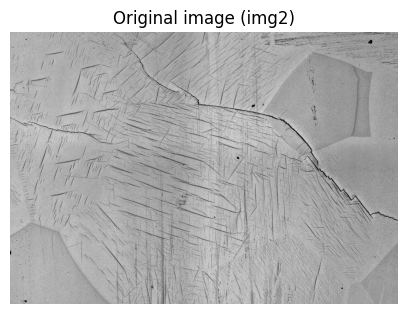

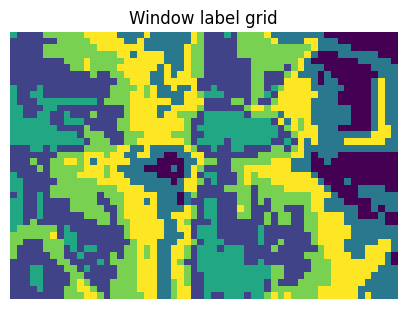

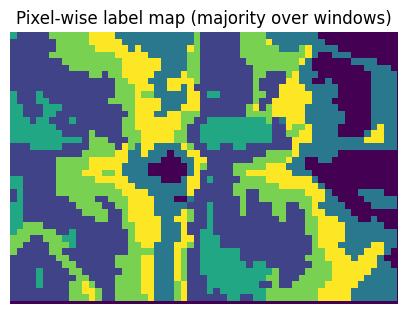

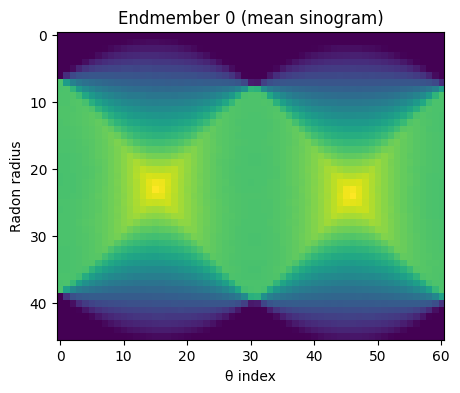

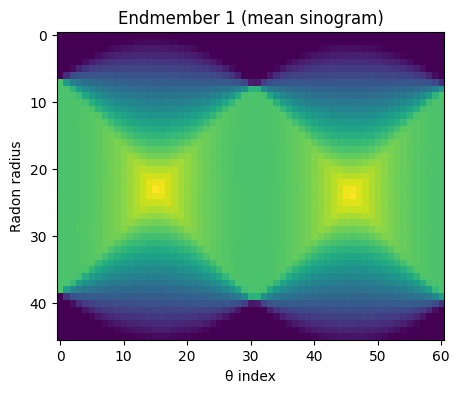

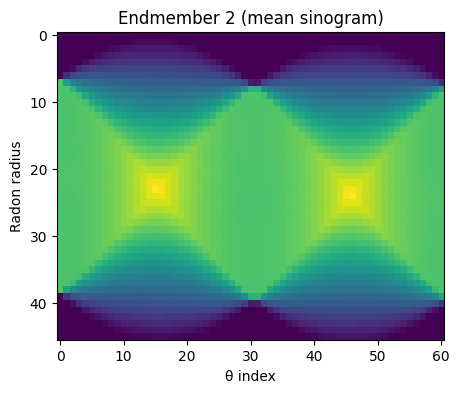

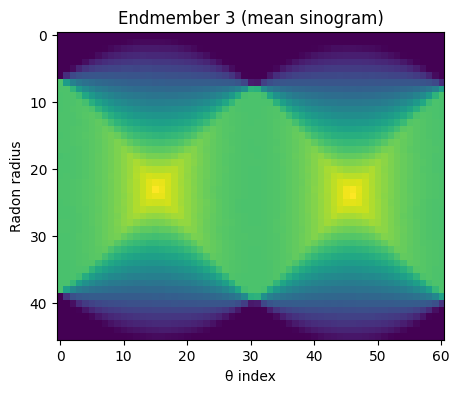

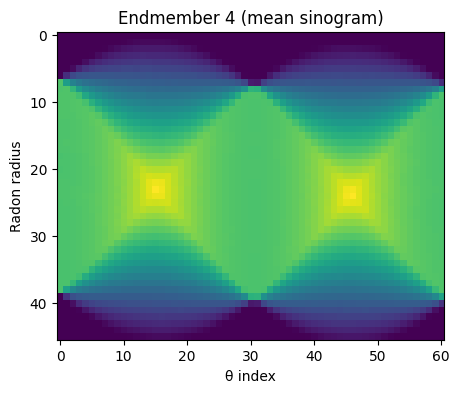

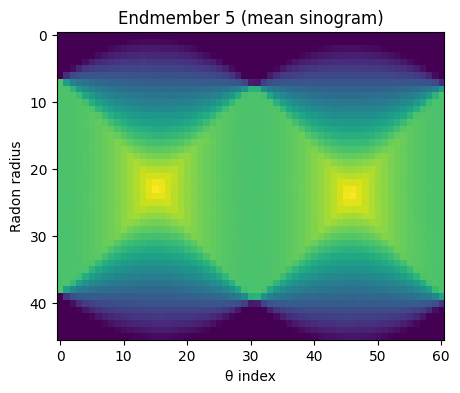

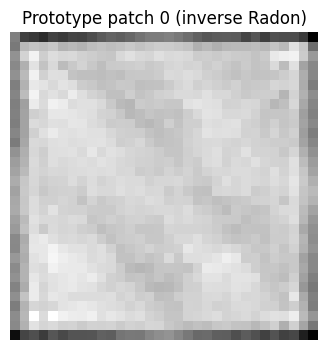

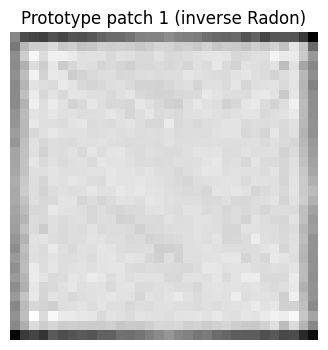

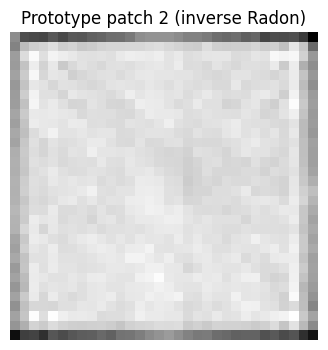

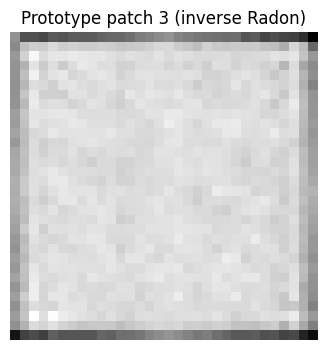

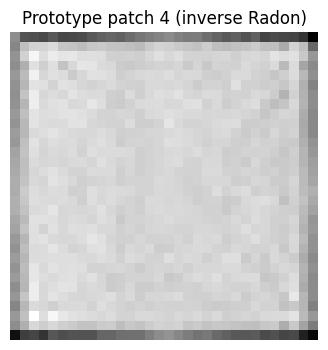

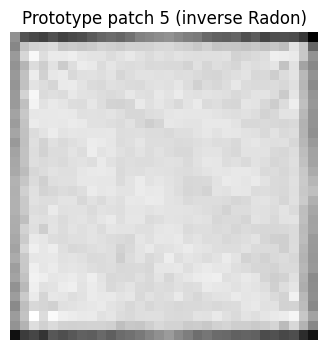

GMM mixture weights: [0.08189655 0.26336207 0.16293103 0.10775862 0.19137931 0.19267241]


In [ ]:
# --- Run on your existing img2 ---
# Adjust params as needed
thetas = np.linspace(0, 180, 61, endpoint=False)

results = radon_gmm_segmentation(
    img=img,                 # <-- uses the existing variable in your Colab
    window_size=(32, 32),
    stride=(16, 16),
    thetas=thetas,
    n_components=6,
    standardize=True,
    random_state=0
)

# --- Visualize ---
show_image(img2, "Original image (img2)")
show_label_map(results['label_grid'], "Window label grid")
show_label_map(results['pixel_label_map'], "Pixel-wise label map (majority over windows)")
show_endmember_sinograms(results['endmember_sinograms'])
show_prototype_patches(results['prototype_patches'])

# (Optional) mixture weights printout
print("GMM mixture weights:", results['weights'])

In [ ]:
def mean_patches_by_label(img, results):
    win_h, win_w = results['params']['window_size']
    stride_h, stride_w = results['params']['stride']
    label_grid = results['label_grid']
    n_rows, n_cols = label_grid.shape
    K = int(results['weights'].shape[0])

    means = []
    counts = []
    for k in range(K):
        accum = np.zeros((win_h, win_w), dtype=float)
        cnt = 0
        for i in range(n_rows):
            r0 = i * stride_h
            for j in range(n_cols):
                c0 = j * stride_w
                if label_grid[i, j] == k:
                    patch = img[r0:r0+win_h, c0:c0+win_w]
                    accum += patch
                    cnt += 1
        means.append(accum / cnt if cnt > 0 else np.zeros((win_h, win_w)))
        counts.append(cnt)
    return means, counts

# --- Soft-assignment (responsibility-weighted) mean patches ---
def mean_patches_by_label_soft(img, results):
    win_h, win_w = results['params']['window_size']
    stride_h, stride_w = results['params']['stride']
    label_grid = results['label_grid']
    n_rows, n_cols = label_grid.shape
    probs = results['probs']  # shape (N, K), same raster order as label_grid iteration below
    K = probs.shape[1]

    accum = [np.zeros((win_h, win_w), dtype=float) for _ in range(K)]
    weight_sum = np.zeros(K, dtype=float)

    idx = 0
    for i in range(n_rows):
        r0 = i * stride_h
        for j in range(n_cols):
            c0 = j * stride_w
            patch = img[r0:r0+win_h, c0:c0+win_w]
            for k in range(K):
                w = probs[idx, k]
                accum[k] += w * patch
                weight_sum[k] += w
            idx += 1

    means = []
    for k in range(K):
        means.append(accum[k] / weight_sum[k] if weight_sum[k] > 0 else np.zeros((win_h, win_w)))
    return means, weight_sum

# --- Visualization helpers ---
def show_mean_patches(patches, counts_or_weights, title_prefix):
    K = len(patches)
    plt.figure(figsize=(3*K, 3))
    for k in range(K):
        plt.subplot(1, K, k+1)
        plt.imshow(patches[k], cmap='gray')
        # counts_or_weights can be int counts or float weights; format nicely
        val = counts_or_weights[k]
        val_str = f"{val:.1f}" if isinstance(val, float) or hasattr(val, "__float__") else str(val)
        plt.title(f"{title_prefix} {k}\n(n={val_str})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

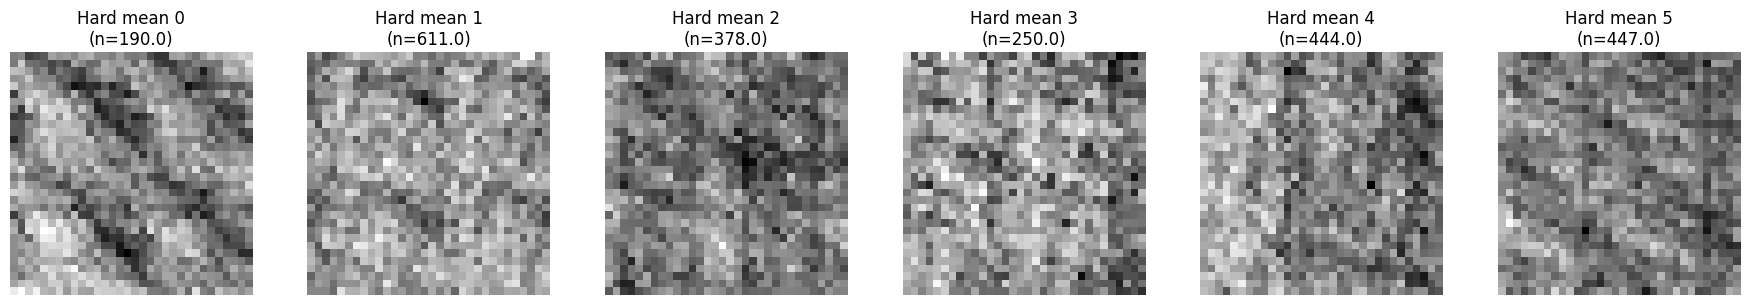

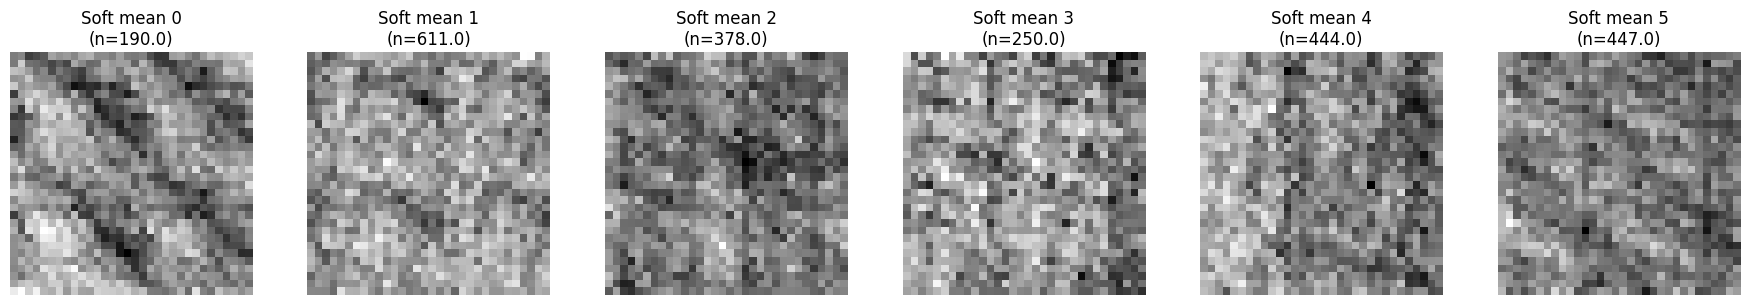

In [ ]:
hard_means, hard_counts = mean_patches_by_label(img, results)
show_mean_patches(hard_means, hard_counts, title_prefix="Hard mean")

soft_means, soft_weights = mean_patches_by_label_soft(img, results)
show_mean_patches(soft_means, soft_weights, title_prefix="Soft mean")

# SAM2 for segmentation

## Segment by point

In [ ]:
# Cell 1 — installs (run as a standalone cell)
%pip -q install -U torch torchvision --index-url https://download.pytorch.org/whl/cu121
%pip -q install "git+https://github.com/facebookresearch/sam2.git" huggingface_hub opencv-python matplotlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.0 MB/s eta 0:00:00


In [ ]:
import numpy as np, cv2, matplotlib.pyplot as plt
from sam2.sam2_image_predictor import SAM2ImagePredictor

# grayscale -> RGB uint8
assert img.ndim == 2
im8 = (255*(img - img.min())/(np.ptp(img)+1e-8)).astype(np.uint8)
rgb = np.stack([im8, im8, im8], axis=-1)

# this downloads and caches the checkpoint the first time
predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-large")
predictor.set_image(rgb)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


sam2_hiera_large.pt:   0%|          | 0.00/898M [00:00<?, ?B/s]

In [ ]:
pts   = np.array([[rgb.shape[1]//2, rgb.shape[0]//2]], dtype=np.float32)
labels= np.array([1], dtype=np.int32)  # 1 = foreground, 0 = background

# ✅ SAM2ImagePredictor uses .predict(...)
masks, scores, logits = predictor.predict(
    point_coords=pts,
    point_labels=labels,
    multimask_output=True  # returns a few alternatives
)

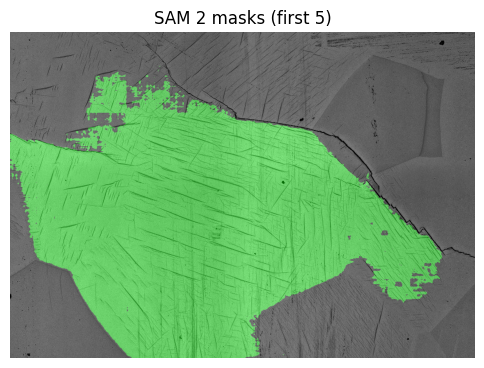

In [ ]:
# quick viz of first 5 masks
plt.figure(figsize=(6,6)); plt.imshow(rgb)

for i, m in enumerate(masks[:5]):
    ms = m.astype(bool)
    overlay = np.zeros_like(rgb); overlay[ms] = (0,255,0)
    plt.imshow(cv2.addWeighted(rgb, 0.6, overlay, 0.4, 0))
plt.axis('off'); plt.title("SAM 2 masks (first 5)"); plt.show()

## Segment anything

In [ ]:
%pip -q install -U torch torchvision --index-url https://download.pytorch.org/whl/cu121
%pip -q install "git+https://github.com/facebookresearch/sam2.git" huggingface_hub opencv-python matplotlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.sam2_image_predictor import SAM2ImagePredictor  # optional, for point/box prompts

# ---------- Helpers ----------
def ensure_rgb_from_gray(gray: np.ndarray) -> np.ndarray:
    assert gray.ndim == 2, "Expected a 2D grayscale image"
    g = gray.astype(np.float32)
    g = (255 * (g - g.min()) / (np.ptp(g) + 1e-8)).astype(np.uint8)
    return np.stack([g, g, g], axis=-1)

def masks_to_labelmap(masks, shape, score_keys=("predicted_iou", "stability_score")) -> np.ndarray:
    """Resolve overlapping instance masks into a single (H,W) label map (0=background)."""
    H, W = shape
    label = np.zeros((H, W), dtype=np.int32)
    score = np.zeros((H, W), dtype=np.float32)

    def quality(m):
        q = 1.0
        for k in score_keys:
            if k in m:
                q *= float(m[k])
        return q

    # Let higher-quality masks overwrite lower-quality ones
    ordered = sorted(masks, key=quality)
    for idx, m in enumerate(ordered, start=1):
        ms = m["segmentation"].astype(bool)
        q = quality(m)
        takeover = ms & (q > score)
        label[takeover] = idx
        score[takeover] = q
    return label

def show_label_overlay(image_rgb: np.ndarray, label_map: np.ndarray, alpha: float = 0.45, seed: int = 0):
    rng = np.random.default_rng(seed)
    n = int(label_map.max())
    palette = np.vstack([[0, 0, 0]] + [rng.integers(0, 256, 3) for _ in range(n)]).astype(np.float32)
    colored = palette[label_map].astype(np.float32)
    out = image_rgb.astype(np.float32)
    mask = (label_map > 0)[..., None]
    out = np.where(mask, (1 - alpha) * out + alpha * colored, out)
    plt.figure(figsize=(7, 7))
    plt.imshow(out.astype(np.uint8))
    plt.axis("off")
    plt.title(f"SAM2 — full-image segmentation ({n} instances)")
    plt.show()

# ---------- Get an image ----------
# Use your existing 'img2' if available; otherwise synthesize a simple test image
if "img" in globals():
    img_gray = np.asarray(img)
    assert img_gray.ndim == 2, "img2 must be a 2D grayscale array"
else:
    # synthetic fallback so the cell runs by itself
    img_gray = np.zeros((384, 512), np.uint8)
    cv2.rectangle(img_gray, (40, 60), (220, 300), 180, -1)
    cv2.circle(img_gray, (360, 200), 80, 130, -1)
    cv2.line(img_gray, (260, 40), (500, 340), 200, 12)
rgb = ensure_rgb_from_gray(img_gray)

# ---------- Load SAM 2 (config string + checkpoint from HF) ----------
# Model family: "sam2_hiera_large.pt" with package config "configs/sam2/sam2_hiera_l.yaml"
cfg_path = "configs/sam2/sam2_hiera_l.yaml"  # package-relative (Hydra can find this)
ckpt_path = hf_hub_download("facebook/sam2-hiera-large", "sam2_hiera_large.pt")  # ~898 MB on first run

sam2_model = build_sam2(cfg_path, ckpt_path)

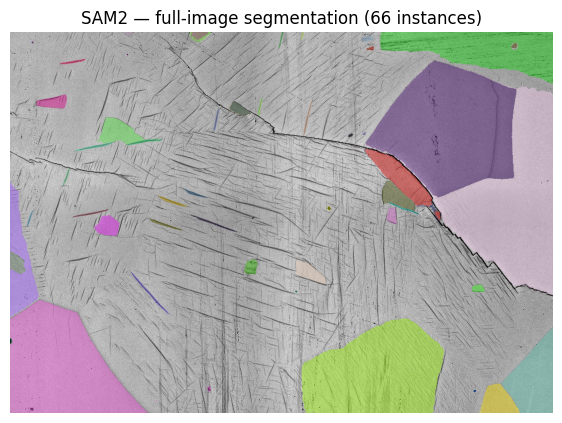

In [ ]:
amg = SAM2AutomaticMaskGenerator(
    sam2_model,
    points_per_side=48,          # increase for denser proposals (slower)
    pred_iou_thresh=0.75, #0.88,
    stability_score_thresh=0.85, #0.92,
    crop_n_layers=2,           # set >0 to enable multi-scale (better for small objects)
)
amg_masks = amg.generate(rgb)    # list of dicts with "segmentation", "area", "bbox", "predicted_iou", ...

label_map = masks_to_labelmap(amg_masks, rgb.shape[:2])
show_label_overlay(rgb, label_map, alpha=0.45, seed=0)

In [ ]:
amg_masks

[{'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]),
  'area': 2398,
  'bbox': [818.0, 612.0, 69.0, 51.0],
  'predicted_iou': 0.9744684100151062,
  'point_coords': [[823.0520629882812, 656.1875]],
  'stability_score': 0.9180982708930969,
  'crop_box': [627.0, 414.0, 319.0, 250.0]},
 {'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ...,  True,  True,  True],
         [False, False, False, ...,  True,  True,  True],
         [False, False, False, ...,  True,  True,  True]]),
  'area': 

Here are the knobs you can set on SAM2AutomaticMaskGenerator (with meanings and defaults):

model (required) – your built SAM2 model (e.g., from build_sam2(...)).
GitHub

points_per_side: int | None = 32 – grid density per side; total probes = points_per_side**2. Exactly one of points_per_side or point_grids must be provided. Higher = more proposals (slower).
Hugging Face

point_grids: list[np.ndarray] | None = None – explicit, normalized
0
,
1
0,1 point grids per crop layer (nth grid used at layer n). Use this instead of points_per_side when you want full control.
Hugging Face

points_per_batch: int = 64 – how many prompts to run at once (speed vs. GPU memory).
Hugging Face

pred_iou_thresh: float = 0.8 – filter by the model’s predicted IoU/quality; masks below are dropped. Typical 0.8–0.9.
Hugging Face

stability_score_thresh: float = 0.95 – filter by mask stability under logit thresholds; drop unstable masks. Typical 0.9–0.97.
Hugging Face

stability_score_offset: float = 1.0 – offset used when computing the stability score.
Hugging Face

mask_threshold: float = 0.0 – logit threshold for binarizing masks (internal step).
Hugging Face

box_nms_thresh: float = 0.7 – IoU threshold for NMS when deduplicating overlapping masks (same crop).
Hugging Face

crop_n_layers: int = 0 – number of multi-scale crop layers (0 = off). >0 improves small-object recall; each layer i uses 2**i crops.
Hugging Face

crop_nms_thresh: float = 0.7 – IoU NMS across different crops.
Hugging Face

crop_overlap_ratio: float = 512/1500 (~0.34) – how much crops overlap in the first layer; later layers downscale overlap.
Hugging Face

crop_n_points_downscale_factor: int = 1 – per layer n, points-per-side is divided by factor**n. Use >1 to keep deeper layers cheaper.
Hugging Face

min_mask_region_area: int = 0 – postprocess to remove tiny disconnected regions/holes (requires OpenCV) when >0.
Hugging Face

output_mode: {"binary_mask","uncompressed_rle","coco_rle"} = "binary_mask" – mask encoding; coco_rle needs pycocotools. For huge images, RLE modes save RAM.
Hugging Face

use_m2m: bool = False – enable a one-step refinement using prior predictions.
Hugging Face

multimask_output: bool = True – keep multiple candidate masks per probe (like SAM’s “multimask”).
Hugging Face

Quick map from your snippet to these options:

points_per_side=24 → denser sampling than default 32? (24² probes).

pred_iou_thresh=0.88, stability_score_thresh=0.92 → stricter quality filters (fewer, cleaner masks).

crop_n_layers=4 → multi-scale search up to 4 layers; better for small features at extra cost.
GitHub
+1

If you want the official example for “segment everything” (and how these affect speed/quality), Meta’s notebook is linked in the repo under automatic_mask_generator_example.ipynb.
GitHub

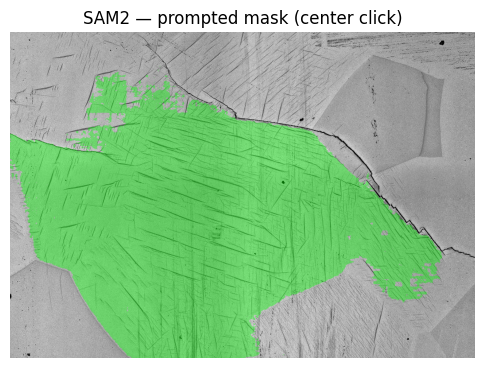

In [ ]:
# Keeps a predictor around if you want point/box prompts after full segmentation
predictor = SAM2ImagePredictor(sam2_model)
predictor.set_image(rgb)

# Single positive click at image center:
pts    = np.array([[rgb.shape[1] // 2, rgb.shape[0] // 2]], dtype=np.float32)
labels = np.array([1], dtype=np.int32)
masks, scores, logits = predictor.predict(point_coords=pts, point_labels=labels, multimask_output=True)
best = masks[int(scores.argmax())].astype(bool)

# Quick overlay for the prompted mask
ov = rgb.copy()
ov[best] = np.clip(0.6 * ov[best] + 0.4 * np.array([0, 255, 0]), 0, 255)
plt.figure(figsize=(6, 6));
plt.imshow(ov.astype(np.uint8));
plt.axis("off");
plt.title("SAM2 — prompted mask (center click)"); plt.show()

# Connect to Gemini and see if we can use LLM in the loop

In [ ]:
#One-time installs (okay to re-run)
!pip -q install -U google-genai pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.7/236.7 kB 24.7 MB/s eta 0:00:00


In [ ]:
import os, numpy as np
from google import genai
from PIL import Image

# 1) Set your key once in Colab (🔑 icon → add "GEMINI_API_KEY")
client = genai.Client(api_key=' add your  key')

# 2) Text-only prompt
resp = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="In 2 sentences, describe how you would segment textures in a micrograph."
)
print(resp.text)

# 3) Multimodal: send your NumPy grayscale image (img2) as a PIL image
assert img.ndim == 2
im8 = (255*(img - img.min())/(np.ptp(img)+1e-8)).astype("uint8")
pil = Image.fromarray(im8)

resp = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[pil, "Describe the dominant structures and any periodicity you see."]
)

print(resp.text)

I would first extract local texture features from the micrograph using methods like Gabor filters or Gray Level Co-occurrence Matrices (GLCM) to quantify patterns. Then, I would apply clustering or classification algorithms to group pixels with similar texture features into distinct segments.
This image appears to be a micrograph (likely a scanning electron micrograph or an optical micrograph after etching) of a material, possibly a metallic alloy, revealing its microstructure.

Here's a breakdown of the dominant structures and periodicity:

**Dominant Structures:**

1.  **Grain Boundaries / Major Cracks:** The most prominent features are several large, irregular, dark, curvilinear lines traversing the image. These lines define distinct regions or "grains." Some of these lines might be actual cracks that have propagated through the material, while others are likely grain boundaries, which are interfaces between crystallites of different orientations.
    *   A major, somewhat jagged da

In [ ]:
# ---- Continue here: add context + constrain output (JSON) ----
import json
from google.genai import types

# If you already have a PIL image as `pil` from above, we reuse it.
# Otherwise, rebuild from your grayscale array (img2 or img).

if 'pil' not in globals():
    gray = img2 if 'img2' in globals() else img
    assert gray.ndim == 2
    im8 = (255*(gray - gray.min())/(np.ptp(gray)+1e-8)).astype("uint8")
    pil = Image.fromarray(im8)

# 1) Authoritative context you want the model to treat as ground truth
context = {
    "domain": "materials microscopy",        # e.g., "AFM", "SEM", "STEM HAADF"
    "modality": "SEM",
    "sample": "titanium alloy",
    "pixel_size_nm": None,                   # fill if known, e.g., 0.25
    "scale_bar_nm": None,
    "expected_structures": ["grain boundaries", "dislocations","grains","contaminants"],
    "forbidden_inferences": [
        "Do not guess chemical composition beyond provided sample info.",
        "Avoid phase identification without clear periodic evidence."
    ],
    "task": "Identify likely structures/periodicities and point to regions with normalized boxes."
}

# 2) Optional ROIs to focus the model (normalized [x,y,w,h] in [0,1])
H, W = np.array(pil).shape[:2]
rois = [
    {"name": "center", "xywh_norm": [0.35, 0.35, 0.30, 0.30]},
]

# 3) Ask for strict JSON output so it’s easy to consume
cfg = types.GenerateContentConfig(
    system_instruction=(
        "You are a careful microscopy analyst. "
        "Treat the provided CONTEXT as ground truth over any priors. "
        "Be conservative; when uncertain, explicitly say so. "
        "Cite visual evidence (texture/contrast/periodicity)."
    ),
    response_mime_type="application/json"
)

# 4) Compose the multimodal prompt (image + context + task)
prompt = (
    "Analyze this microscopy image using the following CONTEXT and FOCUS_ROIS.\n\n"
    "CONTEXT:\n```json\n" + json.dumps(context, indent=2) + "\n```\n"
    "FOCUS_ROIS:\n```json\n" + json.dumps(rois, indent=2) + "\n```\n\n"
    "Return a JSON object with keys:\n"
    "  - global_summary: short paragraph\n"
    "  - findings: array of {name, confidence (0..1), description, bbox_xywh_norm:[x,y,w,h] or null}\n"
    "  - open_questions: array of strings\n"
)

resp = client.models.generate_content(
    model="gemini-2.5-pro",              # use -flash if you want speed over depth
    contents=[pil, prompt],
    config=cfg
)

# 5) Parse/print the JSON response
try:
    report = json.loads(resp.text) if isinstance(resp.text, str) else resp.parsed
except Exception:
    report = resp.text  # fallback

print(report)

{'global_summary': 'The SEM image displays a polycrystalline microstructure of a titanium alloy. Several large grains are visible, distinguished by differences in grayscale contrast, which likely corresponds to variations in crystallographic orientation. A prominent grain, occupying the majority of the image, exhibits a dense network of fine, linear features arranged in multiple parallel sets, indicative of significant plastic deformation. The grains are separated by well-defined, dark lines, which appear to be grain boundaries, some of which may have undergone cracking. The absence of a scale bar prevents any quantitative measurement of feature sizes.', 'findings': [{'name': 'Grain', 'confidence': 1.0, 'description': 'A large grain dominates the central and left portions of the micrograph, characterized by a dense internal network of linear features. It is clearly delineated from adjacent grains by a distinct boundary.', 'bbox_xywh_norm': [0.01, 0.01, 0.8, 0.98]}, {'name': 'Grain', 'c

In [ ]:
print(report.keys())

dict_keys(['global_summary', 'findings', 'open_questions'])


In [ ]:
report['global_summary']

'The SEM image displays a polycrystalline microstructure of a titanium alloy. Several large grains are visible, distinguished by differences in grayscale contrast, which likely corresponds to variations in crystallographic orientation. A prominent grain, occupying the majority of the image, exhibits a dense network of fine, linear features arranged in multiple parallel sets, indicative of significant plastic deformation. The grains are separated by well-defined, dark lines, which appear to be grain boundaries, some of which may have undergone cracking. The absence of a scale bar prevents any quantitative measurement of feature sizes.'

In [ ]:
report['findings'];

In [ ]:
report['open_questions']

['What is the physical scale of the features observed? A scale bar is necessary for any quantitative analysis.',
 'Are the dense linear features confirmed to be slip bands, or could they be fine twins or a lamellar precipitate phase? Higher resolution imaging or techniques like EBSD would be needed for confirmation.',
 'Is the prominent feature between grains a simple grain boundary or an intergranular crack? While it appears to be a crack, higher magnification or cross-sectional analysis is needed to be certain.',
 'What is the thermomechanical history of this alloy? This information is critical for correctly interpreting the observed deformation features.']

In [ ]:
# print report so thet lines are wrapped and all are visible on the screen
import json

# Use json.dumps with indent for pretty printing
print(json.dumps(report, indent=2))

{
  "global_summary": "The SEM image displays a polycrystalline microstructure of a titanium alloy. Several large grains are visible, distinguished by differences in grayscale contrast, which likely corresponds to variations in crystallographic orientation. A prominent grain, occupying the majority of the image, exhibits a dense network of fine, linear features arranged in multiple parallel sets, indicative of significant plastic deformation. The grains are separated by well-defined, dark lines, which appear to be grain boundaries, some of which may have undergone cracking. The absence of a scale bar prevents any quantitative measurement of feature sizes.",
  "findings": [
    {
      "name": "Grain",
      "confidence": 1.0,
      "description": "A large grain dominates the central and left portions of the micrograph, characterized by a dense internal network of linear features. It is clearly delineated from adjacent grains by a distinct boundary.",
      "bbox_xywh_norm": [
        0

# Combining SAM2 and Gemini

Gemini summary:
 SEM micrograph of a polycrystalline material displaying features indicative of extensive plastic deformation and fracture. The microstructure is composed of large grains which contain a high density of fine, linear features consistent with slip bands. A prominent crack propagates across the image, appearing to follow both grain boundaries (intergranular) and cut through grains (transgranular).
Num findings: 6


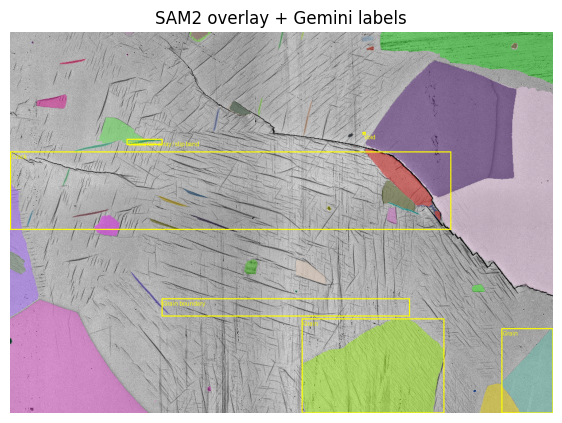

Proposed ROIs: [{'label': 'elongated boundary', 'bbox_xywh_norm': [0.0, 0.35, 1.0, 0.25]}, {'label': 'defect-rich area', 'bbox_xywh_norm': [0.2, 0.55, 0.5, 0.35]}, {'label': 'elongated boundary', 'bbox_xywh_norm': [0.55, 0.45, 0.25, 0.4]}] … total: 5


In [ ]:
# ==== SAM ↔ Gemini glue (assumes `client`, `sam2_model`, and `rgb` exist) ====
import json, numpy as np, matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.sam2_image_predictor import SAM2ImagePredictor
from google.genai import types

# ---------- Image sanity (reuse rgb if present; else build from img2/img) ----------
if 'rgb' not in globals():
    gray = img if 'img' in globals() else img
    assert gray.ndim == 2, "Need a 2D grayscale array (img/img2)"
    g = (255*(gray - gray.min())/(np.ptp(gray)+1e-8)).astype(np.uint8)
    rgb = np.stack([g,g,g], axis=-1)

H, W = rgb.shape[:2]
raw_pil = Image.fromarray(rgb)

# ---------- Utilities ----------
def masks_to_labelmap(masks, shape, score_keys=("predicted_iou","stability_score")):
    """Resolve overlaps into a single (H,W) label map (0=background)."""
    H, W = shape
    label = np.zeros((H, W), np.int32)
    score = np.zeros((H, W), np.float32)

    def q(m):
        s = 1.0
        for k in score_keys:
            if k in m: s *= float(m[k])
        # fallback to area if no scores present
        if s == 1.0 and "area" in m: s = float(m["area"])
        return s

    for idx, m in enumerate(sorted(masks, key=q), start=1):  # low → high, let high overwrite
        ms = m["segmentation"]
        if not isinstance(ms, np.ndarray):
            # if output_mode wasn't "binary_mask", you'd need to decode RLE here
            continue
        ms = ms.astype(bool)
        s = q(m)
        takeover = ms & (s > score)
        label[takeover] = idx
        score[takeover] = s
    return label

def make_overlay(image_rgb, label_map, alpha=0.45, seed=0):
    rng = np.random.default_rng(seed)
    n = int(label_map.max())
    palette = np.vstack([[0,0,0]] + [rng.integers(0,256,3) for _ in range(n)]).astype(np.float32)
    colored = palette[label_map].astype(np.float32)
    out = image_rgb.astype(np.float32)
    mask = (label_map > 0)[..., None]
    out = np.where(mask, (1-alpha)*out + alpha*colored, out)
    return out.astype(np.uint8)

def compute_instance_descriptors(label_map):
    desc = []
    ids = np.unique(label_map)
    ids = ids[ids > 0]
    for rid in ids:
        ms = (label_map == rid)
        ys, xs = np.where(ms)
        if xs.size == 0:
            continue
        x0, x1 = xs.min(), xs.max()
        y0, y1 = ys.min(), ys.max()
        bbox = [x0/W, y0/H, (x1-x0+1)/W, (y1-y0+1)/H]  # normalized [x,y,w,h]
        area = int(ms.sum())
        # crude elongation via bbox aspect ratio
        ar = float((x1-x0+1) / (y1-y0+1))
        desc.append({"id": int(rid), "area_px": area, "bbox_xywh_norm": bbox, "bbox_aspect_ratio": ar})
    return desc

def draw_gemini_boxes(overlay_pil, findings, color=(255,255,0)):
    im = overlay_pil.copy()
    dr = ImageDraw.Draw(im)
    for f in findings:
        box = f.get("bbox_xywh_norm")
        name = f.get("name", "roi")
        if not box:
            continue
        x,y,w,h = box
        x0, y0 = int(x*W), int(y*H)
        x1, y1 = int((x+w)*W), int((y+h)*H)
        dr.rectangle([x0,y0,x1,y1], outline=color, width=2)
        dr.text((x0+3, y0+3), name, fill=color)
    return im

# ---------- A) SAM2 → Gemini: get semantics for segments ----------
# Generate instance masks if not already present
if 'amg_masks' not in globals():
    amg = SAM2AutomaticMaskGenerator(
        sam2_model,
        points_per_side=24,
        pred_iou_thresh=0.88,
        stability_score_thresh=0.92,
        crop_n_layers=0,  # set >0 for multi-scale if you need small features
    )
    amg_masks = amg.generate(rgb)

label_map = masks_to_labelmap(amg_masks, (H, W))
overlay = make_overlay(rgb, label_map, alpha=0.45, seed=0)
overlay_pil = Image.fromarray(overlay)
instances = compute_instance_descriptors(label_map)

# Context you want Gemini to anchor on (edit as needed)
context = {
    "domain": "materials microscopy",
    "modality": "SEM",          # put "STEM HAADF", "AFM", etc. if known
    "pixel_size_nm": None,              # fill if known
    "expected_structures": ["grain boundaries","dislocations","voids"],
    "forbidden": ["no composition guesses beyond provided info"]
}

schema = {
  "type":"object",
  "properties":{
    "global_summary":{"type":"string"},
    "findings":{"type":"array","items":{
      "type":"object",
      "properties":{
        "instance_id":{"type":"integer"},
        "name":{"type":"string"},
        "confidence":{"type":"number"},
        "description":{"type":"string"},
        "bbox_xywh_norm":{"type":"array","items":{"type":"number"}}
      },
      "required":["instance_id","name","confidence","description"]
    }},
    "open_questions":{"type":"array","items":{"type":"string"}}
  },
  "required":["global_summary","findings"]
}

cfg_sem = types.GenerateContentConfig(
    system_instruction=("You are a careful microscopy analyst. "
                        "Use CONTEXT as ground truth. Be conservative; cite visible evidence."),
    response_mime_type="application/json",
    response_schema=schema
)

prompt_sem = (
  "You are given a micrograph and a colored overlay of algorithmic segments (SAM). "
  "Use the CONTEXT and INSTANCE_DESCRIPTORS to propose concise labels for segments by instance_id. "
  "Return JSON with global_summary, findings[{instance_id,name,confidence,description,bbox_xywh_norm}], "
  "and open_questions[].\n\n"
  "CONTEXT:\n```json\n"+json.dumps(context, indent=2)+"\n```\n"
  "INSTANCE_DESCRIPTORS:\n```json\n"+json.dumps(instances[:50], indent=2)+"\n```"
)

resp_sem = client.models.generate_content(
    model="gemini-2.5-pro",
    contents=[raw_pil, overlay_pil, prompt_sem],
    config=cfg_sem
)

report = resp_sem.parsed if hasattr(resp_sem, "parsed") and resp_sem.parsed else json.loads(resp_sem.text)
print("Gemini summary:\n", report.get("global_summary", ""))
print("Num findings:", len(report.get("findings", [])))

# Visualize Gemini-proposed boxes (if present)
overlay_with_boxes = draw_gemini_boxes(overlay_pil, report.get("findings", []), color=(255,255,0))
plt.figure(figsize=(7,7)); plt.imshow(overlay_with_boxes); plt.axis("off"); plt.title("SAM2 overlay + Gemini labels"); plt.show()

# ---------- B) Gemini → SAM2: propose ROIs, refine with predictor ----------
roi_schema = {
  "type":"object",
  "properties":{"rois":{"type":"array","items":{
    "type":"object",
    "properties":{
      "label":{"type":"string"},
      "bbox_xywh_norm":{"type":"array","items":{"type":"number"}, "minItems":4, "maxItems":4}
    },
    "required":["label","bbox_xywh_norm"]
  }}},
  "required":["rois"]
}
cfg_rois = types.GenerateContentConfig(
    response_mime_type="application/json",
    response_schema=roi_schema
)
ask_rois = ("Propose up to 5 regions likely to contain elongated boundaries or defect-rich areas. "
            "Return JSON rois[{label,bbox_xywh_norm}].")
resp_rois = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[raw_pil, overlay_pil, ask_rois],
    config=cfg_rois
)
rois = (resp_rois.parsed or {}).get("rois", [])
print("Proposed ROIs:", rois[:3], "… total:", len(rois))

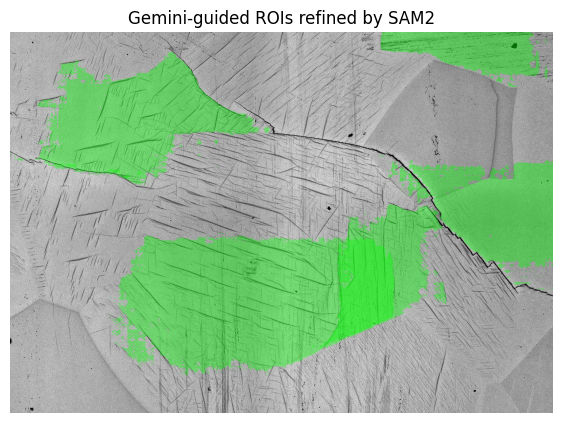

In [ ]:
# Refine each ROI with SAM2 predictor
predictor = SAM2ImagePredictor(sam2_model)
predictor.set_image(rgb)

refined = []
for r in rois:
    x,y,w,h = r["bbox_xywh_norm"]
    box = np.array([x*W, y*H, (x+w)*W, (y+h)*H], np.float32)
    mk, sc, _ = predictor.predict(box=box, multimask_output=True)
    best = mk[int(sc.argmax())].astype(bool)
    refined.append({"label": r["label"], "mask": best})

# Show refined ROI masks atop the image
ov = rgb.copy().astype(np.float32)
for rr in refined:
    m = rr["mask"]
    color = np.array([0,255,0], np.float32)
    ov[m] = 0.6*ov[m] + 0.4*color
plt.figure(figsize=(7,7));
plt.imshow(ov.astype(np.uint8));
plt.axis("off");
plt.title("Gemini-guided ROIs refined by SAM2");
plt.show()

# Interactive model

In [ ]:
# ===================== Text-Guided Interactive Segmentation Loop =====================
import json, numpy as np, matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from google.genai import types
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.sam2_image_predictor import SAM2ImagePredictor

# ---------- Image & model sanity ----------
if 'rgb' not in globals():
    assert 'img2' in globals(), "Need `rgb` or `img2` in memory."
    g = img2.astype(np.float32)
    g8 = (255*(g - g.min())/(g.ptp()+1e-8)).astype(np.uint8)
    rgb = np.stack([g8, g8, g8], axis=-1)

H, W = rgb.shape[:2]
raw_pil = Image.fromarray(rgb)

# ---------- Helpers ----------
def masks_to_labelmap(masks, shape, score_keys=("predicted_iou","stability_score")):
    """Resolve overlaps into a single (H,W) label map (0=background)."""
    H, W = shape
    label = np.zeros((H, W), np.int32)
    score = np.zeros((H, W), np.float32)
    def q(m):
        s = 1.0
        for k in score_keys:
            if k in m: s *= float(m[k])
        if s == 1.0 and "area" in m:  # fallback
            s = float(m["area"])
        return s
    for idx, m in enumerate(sorted(masks, key=q), start=1):  # low→high; high overwrites
        ms = m["segmentation"]
        if not isinstance(ms, np.ndarray):
            continue  # (RLE modes would need decoding)
        ms = ms.astype(bool)
        s = q(m)
        take = ms & (s > score)
        label[take] = idx
        score[take] = s
    return label

def labelmap_overlay(image_rgb, label_map, alpha=0.45, seed=0):
    rng = np.random.default_rng(seed)
    n = int(label_map.max())
    palette = np.vstack([[0,0,0]] + [rng.integers(0,256,3) for _ in range(n)]).astype(np.float32)
    colored = palette[label_map].astype(np.float32)
    out = image_rgb.astype(np.float32)
    mask = (label_map > 0)[..., None]
    out = np.where(mask, (1-alpha)*out + alpha*colored, out)
    return out.astype(np.uint8)

def integrate_binary_mask(label_map, mask_bool):
    """Assign a new instance id for the mask; return updated label map."""
    new_id = int(label_map.max()) + 1
    lm = label_map.copy()
    lm[mask_bool] = new_id
    return lm

def compute_instance_descriptors(label_map):
    """Simple per-instance descriptors + normalized boxes for Gemini context."""
    desc = []
    ids = np.unique(label_map); ids = ids[ids > 0]
    for rid in ids:
        ms = (label_map == rid)
        ys, xs = np.where(ms)
        if xs.size == 0:
            continue
        x0, x1 = xs.min(), xs.max()
        y0, y1 = ys.min(), ys.max()
        bbox = [x0/W, y0/H, (x1-x0+1)/W, (y1-y0+1)/H]
        area = int(ms.sum())
        ar = float((x1-x0+1) / (y1-y0+1))
        desc.append({"id": int(rid), "area_px": area, "bbox_xywh_norm": bbox, "bbox_aspect_ratio": ar})
    return desc

def draw_boxes(pil_image, boxes, color=(255,255,0)):
    im = pil_image.copy()
    dr = ImageDraw.Draw(im)
    for b in boxes:
        x,y,w,h = b
        x0,y0 = int(x*W), int(y*H); x1,y1 = int((x+w)*W), int((y+h)*H)
        dr.rectangle([x0,y0,x1,y1], outline=color, width=2)
    return im

# ---------- SAM2 primitives ----------
_predictor = None
def get_predictor():
    global _predictor
    if _predictor is None:
        _predictor = SAM2ImagePredictor(sam2_model)
        _predictor.set_image(rgb)
    return _predictor

def sam2_segment_everything(points_per_side=24, pred_iou_thresh=0.88, stability_score_thresh=0.92, crop_n_layers=0):
    amg = SAM2AutomaticMaskGenerator(
        sam2_model,
        points_per_side=points_per_side,
        pred_iou_thresh=pred_iou_thresh,
        stability_score_thresh=stability_score_thresh,
        crop_n_layers=crop_n_layers
    )
    return amg.generate(rgb)

def sam2_from_boxes(boxes_xywh_norm):
    pred = get_predictor()
    masks_out = []
    for b in boxes_xywh_norm:
        x,y,w,h = b
        box = np.array([x*W, y*H, (x+w)*W, (y+h)*H], np.float32)
        mk, sc, _ = pred.predict(box=box, multimask_output=True)
        best = mk[int(sc.argmax())].astype(bool)
        masks_out.append(best)
    return masks_out

def sam2_from_points(points_xy_norm, point_labels):
    pred = get_predictor()
    pts = np.array([[x*W, y*H] for (x,y) in points_xy_norm], np.float32)
    labs = np.array(point_labels, np.int32)
    mk, sc, _ = pred.predict(point_coords=pts, point_labels=labs, multimask_output=True)
    # If multiple points are given at once, you still get multiple candidate masks for the set
    best = mk[int(sc.argmax())].astype(bool)
    return [best]

# ---------- Gemini instruction → actions ----------
# Fixed schema: `params` has properties (non-empty) to satisfy Gemini's JSON schema requirements.
_action_schema = {
  "type":"object",
  "properties":{
    "actions":{
      "type":"array",
      "items":{
        "type":"object",
        "properties":{
          "op":{
            "type":"string",
            "enum":["segment_everything","propose_rois","add_boxes","add_points","stop"]
          },
          "params":{
            "type":"object",
            "properties":{
              "points_per_side":{"type":"integer","minimum":1},
              "pred_iou_thresh":{"type":"number","minimum":0,"maximum":1},
              "stability_score_thresh":{"type":"number","minimum":0,"maximum":1},
              "crop_n_layers":{"type":"integer","minimum":0},
              "criteria":{"type":"string"},
              "count":{"type":"integer","minimum":1}
            }
          },
          "boxes_xywh_norm":{
            "type":"array",
            "items":{
              "type":"array",
              "items":{"type":"number"},
              "minItems":4,"maxItems":4
            }
          },
          "points_xy_norm":{
            "type":"array",
            "items":{
              "type":"array",
              "items":{"type":"number"},
              "minItems":2,"maxItems":2
            }
          },
          "point_labels":{
            "type":"array",
            "items":{"type":"integer"}
          }
        },
        "required":["op"]
      }
    }
  },
  "required":["actions"]
}

_cfg_router = types.GenerateContentConfig(
    system_instruction=("You are a planner that converts user intent into concrete segmentation actions.\n"
                        "Return JSON with an 'actions' list. Use normalized coordinates [0,1].\n"
                        "Use operations: segment_everything (with params points_per_side, pred_iou_thresh, "
                        "stability_score_thresh, crop_n_layers), propose_rois (with 'criteria' and 'count'), "
                        "add_boxes (with boxes_xywh_norm), add_points (with points_xy_norm and point_labels), stop."),
    response_mime_type="application/json",
    response_schema=_action_schema
)

def route_instruction_to_actions(instruction, label_map=None):
    """Send instruction + context to Gemini; get back an action list."""
    context = {
        "image_shape_hw": [int(H), int(W)],
        "num_instances": int(label_map.max()) if label_map is not None else 0,
        "examples": [
            {"ask":"segment everything", "actions":[{"op":"segment_everything","params":{"points_per_side":24}}]},
            {"ask":"focus on elongated boundaries", "actions":[{"op":"propose_rois","params":{"criteria":"elongated boundaries","count":4}}]},
            {"ask":"refine the bright blob on the right", "actions":[{"op":"propose_rois","params":{"criteria":"bright blob on right","count":2}}]},
            {"ask":"add a box around center", "actions":[{"op":"add_boxes","boxes_xywh_norm":[[0.4,0.4,0.2,0.2]]}]},
            {"ask":"click center", "actions":[{"op":"add_points","points_xy_norm":[[0.5,0.5]],"point_labels":[1]}]}
        ]
    }
    prompt = (
        "Translate the user instruction into actionable segmentation steps.\n"
        "IMAGE_CONTEXT:\n```json\n"+json.dumps(context, indent=2)+"\n```\n"
        "USER_INSTRUCTION:\n"+instruction+"\n"
        "Return JSON only."
    )
    overlay = labelmap_overlay(rgb, label_map) if label_map is not None else rgb
    overlay_pil = Image.fromarray(overlay)
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[raw_pil, overlay_pil, prompt],
        config=_cfg_router
    )
    parsed = resp.parsed if hasattr(resp, "parsed") and resp.parsed else json.loads(resp.text)
    return parsed.get("actions", [])

# ---------- State + one interactive step ----------
STATE = {"label_map": np.zeros((H,W), np.int32)}  # start empty

def interactive_step(instruction, verbose=True):
    """One step: route instruction → actions → apply → visualize."""
    lm = STATE["label_map"]
    actions = route_instruction_to_actions(instruction, label_map=lm)

    # If the router proposes ROIs, ask Gemini for concrete boxes (helper stage)
    def propose_boxes(criteria="interesting regions", count=4):
        roi_schema = {
          "type":"object",
          "properties":{"rois":{"type":"array","items":{
            "type":"object",
            "properties":{
              "label":{"type":"string"},
              "bbox_xywh_norm":{"type":"array","items":{"type":"number"}, "minItems":4, "maxItems":4}
            },
            "required":["bbox_xywh_norm"]
          }}},
          "required":["rois"]
        }
        cfg_rois = types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=roi_schema
        )
        ask = (f"Propose up to {count} ROIs for: {criteria}. "
               "Return JSON rois[{label,bbox_xywh_norm}] with normalized coordinates.")
        resp = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=[raw_pil, Image.fromarray(labelmap_overlay(rgb, lm)), ask],
            config=cfg_rois
        )
        rois = (resp.parsed or {}).get("rois", [])
        return [r["bbox_xywh_norm"] for r in rois if "bbox_xywh_norm" in r]

    applied = []
    for act in actions:
        op = act["op"]
        if op == "segment_everything":
            p = {"points_per_side":24, "pred_iou_thresh":0.88, "stability_score_thresh":0.92, "crop_n_layers":0}
            p.update(act.get("params", {}))
            masks = sam2_segment_everything(**p)
            lm = masks_to_labelmap(masks, (H,W))
            applied.append(("segment_everything", p, f"{len(masks)} raw masks"))
        elif op == "propose_rois":
            p = act.get("params", {})
            boxes = propose_boxes(criteria=p.get("criteria","interesting regions"), count=int(p.get("count",4)))
            if boxes:
                # immediately refine proposed boxes
                masks = sam2_from_boxes(boxes)
                for m in masks:
                    lm = integrate_binary_mask(lm, m)
                applied.append(("add_boxes[from_proposal]", {"n_boxes":len(boxes)}, f"{len(masks)} masks"))
        elif op == "add_boxes":
            boxes = act.get("boxes_xywh_norm", [])
            if boxes:
                masks = sam2_from_boxes(boxes)
                for m in masks:
                    lm = integrate_binary_mask(lm, m)
                applied.append(("add_boxes", {"n_boxes":len(boxes)}, f"{len(masks)} masks"))
        elif op == "add_points":
            pts = act.get("points_xy_norm", [])
            labs = act.get("point_labels", [1]*len(pts))
            if pts:
                masks = sam2_from_points(pts, labs)
                for m in masks:
                    lm = integrate_binary_mask(lm, m)
                applied.append(("add_points", {"n_points":len(pts)}, f"{len(masks)} masks"))
        elif op == "stop":
            applied.append(("stop", {}, ""))

    STATE["label_map"] = lm
    overlay = labelmap_overlay(rgb, lm)
    if verbose:
        print("Applied actions:", applied if applied else "(none)")
        plt.figure(figsize=(7,7)); plt.imshow(overlay); plt.axis("off")
        plt.title(f"Interactive overlay — {int(lm.max())} instances"); plt.show()
    return lm

# ---------- (Optional) Tiny REPL ----------
def run_repl():
    print("Type instructions (e.g., 'segment everything', 'focus on elongated boundaries', 'stop').")
    while True:
        try:
            ins = input(">> ").strip()
        except EOFError:
            break
        if not ins:
            continue
        lm = interactive_step(ins)
        if ins.lower() in {"stop","quit","exit"}:
            break

# Example usage:
# interactive_step("segment everything")
# interactive_step("focus on elongated boundaries")


Type instructions (e.g., 'segment everything', 'focus on elongated boundaries', 'stop').
>> segment everything
Applied actions: [('segment_everything', {'points_per_side': 24, 'pred_iou_thresh': 0.88, 'stability_score_thresh': 0.92, 'crop_n_layers': 0}, '8 raw masks')]


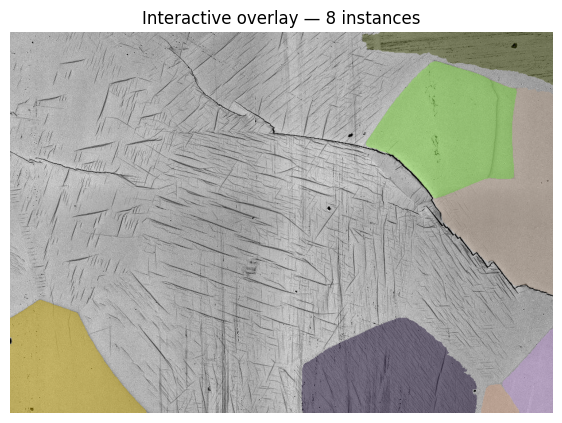

KeyboardInterrupt: Interrupted by user

In [ ]:
run_repl()

Type instructions (e.g., 'segment everything', 'focus on elongated boundaries', 'stop').
>> find cracks
Applied actions: [('add_boxes[from_proposal]', {'n_boxes': 2}, '2 masks')]


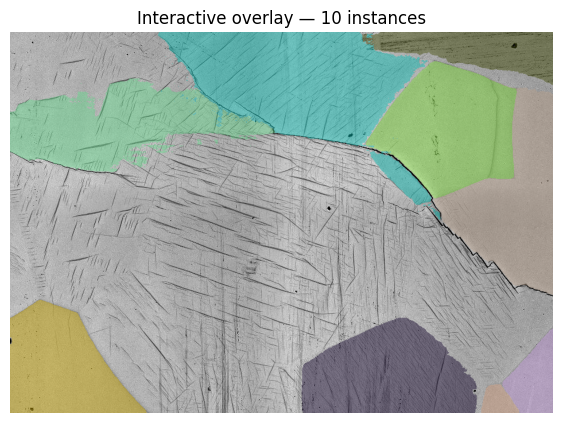

KeyboardInterrupt: Interrupted by user

In [ ]:
run_repl()
